In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

## Impoering the librries

In [2]:
df = pd.read_csv("dirty_cafe_sales.csv")
df.head()



,Transaction ID,Item,Quantity,Price Per Unit,Total Spent,Payment Method,Location,Transaction Date
0,TXN_1961373,Coffee,2,2.0,4.0,Credit Card,Takeaway,2023-09-08
1,TXN_4977031,Cake,4,3.0,12.0,Cash,In-store,2023-05-16
2,TXN_4271903,Cookie,4,1.0,ERROR,Credit Card,In-store,2023-07-19
3,TXN_7034554,Salad,2,5.0,10.0,UNKNOWN,UNKNOWN,2023-04-27
4,TXN_3160411,Coffee,2,2.0,4.0,Digital Wallet,In-store,2023-06-11


## Inspecting The data

In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype
---  ------            --------------  -----
 0   Transaction ID    10000 non-null  str  
 1   Item              9667 non-null   str  
 2   Quantity          9862 non-null   str  
 3   Price Per Unit    9821 non-null   str  
 4   Total Spent       9827 non-null   str  
 5   Payment Method    7421 non-null   str  
 6   Location          6735 non-null   str  
 7   Transaction Date  9841 non-null   str  
dtypes: str(8)
memory usage: 1.1 MB


In [4]:
# df.describe()
df.shape

(10000, 8)

In [5]:
df.isnull().sum()

Transaction ID         0
Item                 333
Quantity             138
Price Per Unit       179
Total Spent          173
Payment Method      2579
Location            3265
Transaction Date     159
dtype: int64

In [6]:
df["Item"].value_counts()
df["Payment Method"].value_counts()
df["Location"].value_counts()
df["Quantity"].value_counts()
df["Price Per Unit"].value_counts()
df["Total Spent"].value_counts()

Total Spent
6.0        979
12.0       939
3.0        930
4.0        923
20.0       746
15.0       734
8.0        677
10.0       524
2.0        497
9.0        479
5.0        468
16.0       444
25.0       259
7.5        237
1.0        232
4.5        225
1.5        205
UNKNOWN    165
ERROR      164
Name: count, dtype: int64

## Handling Missing and Invalid values

### Making a copy of the original Data

In [7]:
clean_df = df.copy()
clean_df

,Transaction ID,Item,Quantity,Price Per Unit,Total Spent,Payment Method,Location,Transaction Date
0,TXN_1961373,Coffee,2,2.0,4.0,Credit Card,Takeaway,2023-09-08
1,TXN_4977031,Cake,4,3.0,12.0,Cash,In-store,2023-05-16
2,TXN_4271903,Cookie,4,1.0,ERROR,Credit Card,In-store,2023-07-19
3,TXN_7034554,Salad,2,5.0,10.0,UNKNOWN,UNKNOWN,2023-04-27
4,TXN_3160411,Coffee,2,2.0,4.0,Digital Wallet,In-store,2023-06-11
...,...,...,...,...,...,...,...,...
9995,TXN_7672686,Coffee,2,2.0,4.0,NaN,UNKNOWN,2023-08-30
9996,TXN_9659401,NaN,3,NaN,3.0,Digital Wallet,NaN,2023-06-02
9997,TXN_5255387,Coffee,4,2.0,8.0,Digital Wallet,NaN,2023-03-02
9998,TXN_7695629,Cookie,3,NaN,3.0,Digital Wallet,NaN,2023-12-02


In [8]:
## Replace "ERROR" in numeric columns as NaN
numeric_columns = ["Quantity", "Price Per Unit", "Total Spent"]
clean_df[numeric_columns] = clean_df[numeric_columns].replace("ERROR", np.nan)


In [9]:
clean_df.head(20)

,Transaction ID,Item,Quantity,Price Per Unit,Total Spent,Payment Method,Location,Transaction Date
0,TXN_1961373,Coffee,2,2.0,4.0,Credit Card,Takeaway,2023-09-08
1,TXN_4977031,Cake,4,3.0,12.0,Cash,In-store,2023-05-16
2,TXN_4271903,Cookie,4,1.0,NaN,Credit Card,In-store,2023-07-19
3,TXN_7034554,Salad,2,5.0,10.0,UNKNOWN,UNKNOWN,2023-04-27
4,TXN_3160411,Coffee,2,2.0,4.0,Digital Wallet,In-store,2023-06-11
5,TXN_2602893,Smoothie,5,4.0,20.0,Credit Card,NaN,2023-03-31
6,TXN_4433211,UNKNOWN,3,3.0,9.0,ERROR,Takeaway,2023-10-06
7,TXN_6699534,Sandwich,4,4.0,16.0,Cash,UNKNOWN,2023-10-28
8,TXN_4717867,NaN,5,3.0,15.0,NaN,Takeaway,2023-07-28
9,TXN_2064365,Sandwich,5,4.0,20.0,NaN,In-store,2023-12-31


In [10]:
## Replacing the error in categorical column with unknown
categorical_columns = ["Item", "Payment Method", "Location"]
clean_df[categorical_columns] = clean_df[categorical_columns].replace("ERROR", "Unknown")
clean_df.head()

,Transaction ID,Item,Quantity,Price Per Unit,Total Spent,Payment Method,Location,Transaction Date
0,TXN_1961373,Coffee,2,2.0,4.0,Credit Card,Takeaway,2023-09-08
1,TXN_4977031,Cake,4,3.0,12.0,Cash,In-store,2023-05-16
2,TXN_4271903,Cookie,4,1.0,NaN,Credit Card,In-store,2023-07-19
3,TXN_7034554,Salad,2,5.0,10.0,UNKNOWN,UNKNOWN,2023-04-27
4,TXN_3160411,Coffee,2,2.0,4.0,Digital Wallet,In-store,2023-06-11


In [11]:
## Standardize the unknown
clean_df[categorical_columns] = clean_df[categorical_columns].replace("UNKNOWN", "Unknown")
clean_df.head()


,Transaction ID,Item,Quantity,Price Per Unit,Total Spent,Payment Method,Location,Transaction Date
0,TXN_1961373,Coffee,2,2.0,4.0,Credit Card,Takeaway,2023-09-08
1,TXN_4977031,Cake,4,3.0,12.0,Cash,In-store,2023-05-16
2,TXN_4271903,Cookie,4,1.0,NaN,Credit Card,In-store,2023-07-19
3,TXN_7034554,Salad,2,5.0,10.0,Unknown,Unknown,2023-04-27
4,TXN_3160411,Coffee,2,2.0,4.0,Digital Wallet,In-store,2023-06-11


In [12]:
clean_df.isnull().sum()

Transaction ID         0
Item                 333
Quantity             308
Price Per Unit       369
Total Spent          337
Payment Method      2579
Location            3265
Transaction Date     159
dtype: int64

In [13]:
clean_df[categorical_columns] = clean_df[categorical_columns].fillna("Unknown")
clean_df.isnull().sum()


Transaction ID        0
Item                  0
Quantity            308
Price Per Unit      369
Total Spent         337
Payment Method        0
Location              0
Transaction Date    159
dtype: int64

## Fixing the Numeric Columns

In [14]:
# convert the column to numeric data type
for column in numeric_columns:
    clean_df[column] = pd.to_numeric(clean_df[column], errors="coerce")
clean_df[numeric_columns].dtypes

Quantity          float64
Price Per Unit    float64
Total Spent       float64
dtype: object

In [15]:
clean_df[numeric_columns].isnull().sum()

Quantity          479
Price Per Unit    533
Total Spent       502
dtype: int64

In [16]:
# check how many tottal we can recover
recoverable_total = (clean_df["Total Spent"].isna() & clean_df["Quantity"].notna() & clean_df["Price Per Unit"].notna())
recoverable_total.sum()

np.int64(462)

In [17]:
# Calculate the expected total
clean_df["Calculated Total"] = clean_df["Quantity"] * clean_df["Price Per Unit"]
clean_df

,Transaction ID,Item,Quantity,Price Per Unit,Total Spent,Payment Method,Location,Transaction Date,Calculated Total
0,TXN_1961373,Coffee,2.0,2.0,4.0,Credit Card,Takeaway,2023-09-08,4.0
1,TXN_4977031,Cake,4.0,3.0,12.0,Cash,In-store,2023-05-16,12.0
2,TXN_4271903,Cookie,4.0,1.0,NaN,Credit Card,In-store,2023-07-19,4.0
3,TXN_7034554,Salad,2.0,5.0,10.0,Unknown,Unknown,2023-04-27,10.0
4,TXN_3160411,Coffee,2.0,2.0,4.0,Digital Wallet,In-store,2023-06-11,4.0
...,...,...,...,...,...,...,...,...,...
9995,TXN_7672686,Coffee,2.0,2.0,4.0,Unknown,Unknown,2023-08-30,4.0
9996,TXN_9659401,Unknown,3.0,NaN,3.0,Digital Wallet,Unknown,2023-06-02,NaN
9997,TXN_5255387,Coffee,4.0,2.0,8.0,Digital Wallet,Unknown,2023-03-02,8.0
9998,TXN_7695629,Cookie,3.0,NaN,3.0,Digital Wallet,Unknown,2023-12-02,NaN


In [18]:
# find the transaction where the total isn wrong
valid_totals = (
    clean_df["Total Spent"].notna() & clean_df["Quantity"].notna() & clean_df["Price Per Unit"].notna()
)
clean_df["Total Difference"] = (
    clean_df["Total Spent"] - clean_df["Calculated Total"]
)
clean_df.head()

,Transaction ID,Item,Quantity,Price Per Unit,Total Spent,Payment Method,Location,Transaction Date,Calculated Total,Total Difference
0,TXN_1961373,Coffee,2.0,2.0,4.0,Credit Card,Takeaway,2023-09-08,4.0,0.0
1,TXN_4977031,Cake,4.0,3.0,12.0,Cash,In-store,2023-05-16,12.0,0.0
2,TXN_4271903,Cookie,4.0,1.0,NaN,Credit Card,In-store,2023-07-19,4.0,NaN
3,TXN_7034554,Salad,2.0,5.0,10.0,Unknown,Unknown,2023-04-27,10.0,0.0
4,TXN_3160411,Coffee,2.0,2.0,4.0,Digital Wallet,In-store,2023-06-11,4.0,0.0


In [19]:
# Get the inconsistent rows
inconsistent_rows = clean_df[
    valid_totals & (clean_df["Total Difference"] != 0)
]

inconsistent_rows

,Transaction ID,Item,Quantity,Price Per Unit,Total Spent,Payment Method,Location,Transaction Date,Calculated Total,Total Difference


In [20]:
# Check the rows with nan
clean_df["Calculated Total"].isna().sum()
# clean_df["Calculated Total"]

np.int64(994)

In [21]:
# replacing the nan in total spent with that of calculated total
clean_df["Valid Total"] = clean_df["Total Spent"].fillna(clean_df["Calculated Total"])
clean_df.head(100)

,Transaction ID,Item,Quantity,Price Per Unit,Total Spent,Payment Method,Location,Transaction Date,Calculated Total,Total Difference,Valid Total
0,TXN_1961373,Coffee,2.0,2.0,4.0,Credit Card,Takeaway,2023-09-08,4.0,0.0,4.0
1,TXN_4977031,Cake,4.0,3.0,12.0,Cash,In-store,2023-05-16,12.0,0.0,12.0
2,TXN_4271903,Cookie,4.0,1.0,NaN,Credit Card,In-store,2023-07-19,4.0,NaN,4.0
3,TXN_7034554,Salad,2.0,5.0,10.0,Unknown,Unknown,2023-04-27,10.0,0.0,10.0
4,TXN_3160411,Coffee,2.0,2.0,4.0,Digital Wallet,In-store,2023-06-11,4.0,0.0,4.0
...,...,...,...,...,...,...,...,...,...,...,...
95,TXN_8268061,Salad,3.0,5.0,15.0,Unknown,Takeaway,2023-08-20,15.0,0.0,15.0
96,TXN_5220895,Salad,5.0,5.0,25.0,Cash,In-store,2023-06-10,25.0,0.0,25.0
97,TXN_3085509,Coffee,4.0,2.0,8.0,Digital Wallet,In-store,2023-04-15,8.0,0.0,8.0
98,TXN_9999113,Juice,4.0,3.0,12.0,Cash,Takeaway,2023-05-27,12.0,0.0,12.0


In [22]:
print("Total Rows", len(clean_df))
print("Missing Valid Total",clean_df["Valid Total"].isna().sum())

Total Rows 10000
Missing Valid Total 40


In [23]:
#Dropping the missing 40 rows in the valid total
clean_df = clean_df.dropna(subset = ["Valid Total"]).copy()
clean_df.shape

(9960, 11)

In [24]:
clean_df.isnull().sum()

Transaction ID         0
Item                   0
Quantity             459
Price Per Unit       513
Total Spent          462
Payment Method         0
Location               0
Transaction Date     158
Calculated Total     954
Total Difference    1416
Valid Total            0
dtype: int64

In [25]:
recoverable_total = (clean_df["Total Spent"].isna() & clean_df["Quantity"].notna() & clean_df["Price Per Unit"].notna())
recoverable_total.sum()

np.int64(462)

In [26]:
#recover missing total spent
clean_df.loc[recoverable_total, "Total Spent"] =( clean_df.loc[recoverable_total, "Quantity"] * clean_df.loc[recoverable_total, "Price Per Unit"])
clean_df["Total Spent"].isna().sum()

np.int64(0)

In [27]:
recoverable_quantity = (clean_df["Total Spent"].notna() & clean_df["Quantity"].isna() & clean_df["Price Per Unit"].notna())
recoverable_quantity.sum()

np.int64(441)

In [28]:
#recover missing quantity
clean_df.loc[recoverable_quantity, "Quantity"] =( clean_df.loc[recoverable_quantity, "Total Spent"] / clean_df.loc[recoverable_quantity, "Price Per Unit"])
clean_df["Quantity"].isna().sum()

np.int64(18)

In [29]:
recoverable_price = (clean_df["Total Spent"].notna() & clean_df["Quantity"].notna() & clean_df["Price Per Unit"].isna())
recoverable_price.sum()

np.int64(495)

In [30]:
#recover missing price
clean_df.loc[recoverable_price, "Price Per Unit"] =( clean_df.loc[recoverable_price, "Total Spent"] / clean_df.loc[recoverable_price, "Quantity"])
clean_df["Price Per Unit"].isna().sum()

np.int64(18)

In [31]:
# dropping the nan in price and quantity
clean_df = clean_df.dropna(subset=["Quantity", "Price Per Unit"]).copy()

In [32]:
clean_df.isnull().sum()

Transaction ID         0
Item                   0
Quantity               0
Price Per Unit         0
Total Spent            0
Payment Method         0
Location               0
Transaction Date     157
Calculated Total     936
Total Difference    1398
Valid Total            0
dtype: int64

In [33]:
# Dropping the columns we created in getting the data needed
clean_df.drop(
    columns=["Calculated Total", "Total Difference", "Valid Total"], 
    inplace = True,
    errors= "ignore"
)



In [34]:
clean_df.columns

Index(['Transaction ID', 'Item', 'Quantity', 'Price Per Unit', 'Total Spent',
       'Payment Method', 'Location', 'Transaction Date'],
      dtype='str')

In [35]:
clean_df["Transaction Date"]

0       2023-09-08
1       2023-05-16
2       2023-07-19
3       2023-04-27
4       2023-06-11
           ...    
9995    2023-08-30
9996    2023-06-02
9997    2023-03-02
9998    2023-12-02
9999    2023-11-07
Name: Transaction Date, Length: 9942, dtype: str

In [36]:
# formating the date in case 
from dateutil import parser

def clean_date(date_str):
    try:
        return parser.parse(date_str, dayfirst=True)
    except Exception:
        return pd.NaT

clean_df["Transaction Date"] = clean_df["Transaction Date"].apply(clean_date)
clean_df["Transaction Date"]

0      2023-08-09
1      2023-05-16
2      2023-07-19
3      2023-04-27
4      2023-11-06
          ...    
9995   2023-08-30
9996   2023-02-06
9997   2023-02-03
9998   2023-02-12
9999   2023-07-11
Name: Transaction Date, Length: 9942, dtype: datetime64[us]

In [37]:
#replacing the missing date with the median of the date
clean_df["Transaction Date"] = clean_df["Transaction Date"].fillna(clean_df["Transaction Date"].median())

In [38]:
clean_df.isna().sum()

Transaction ID      0
Item                0
Quantity            0
Price Per Unit      0
Total Spent         0
Payment Method      0
Location            0
Transaction Date    0
dtype: int64

In [39]:
clean_df.head(20)

,Transaction ID,Item,Quantity,Price Per Unit,Total Spent,Payment Method,Location,Transaction Date
0,TXN_1961373,Coffee,2.0,2.0,4.0,Credit Card,Takeaway,2023-08-09
1,TXN_4977031,Cake,4.0,3.0,12.0,Cash,In-store,2023-05-16
2,TXN_4271903,Cookie,4.0,1.0,4.0,Credit Card,In-store,2023-07-19
3,TXN_7034554,Salad,2.0,5.0,10.0,Unknown,Unknown,2023-04-27
4,TXN_3160411,Coffee,2.0,2.0,4.0,Digital Wallet,In-store,2023-11-06
5,TXN_2602893,Smoothie,5.0,4.0,20.0,Credit Card,Unknown,2023-03-31
6,TXN_4433211,Unknown,3.0,3.0,9.0,Unknown,Takeaway,2023-06-10
7,TXN_6699534,Sandwich,4.0,4.0,16.0,Cash,Unknown,2023-10-28
8,TXN_4717867,Unknown,5.0,3.0,15.0,Unknown,Takeaway,2023-07-28
9,TXN_2064365,Sandwich,5.0,4.0,20.0,Unknown,In-store,2023-12-31


In [40]:
clean_df.dtypes

Transaction ID                 str
Item                           str
Quantity                   float64
Price Per Unit             float64
Total Spent                float64
Payment Method                 str
Location                       str
Transaction Date    datetime64[us]
dtype: object

In [41]:
# checking for duplicate
clean_df.duplicated().sum()

np.int64(0)

In [42]:
# check the values in the numeric data
clean_df[numeric_columns].describe()

,Quantity,Price Per Unit,Total Spent
count,9942.000000,9942.000000,9942.000000
mean,3.025749,2.947848,8.931855
std,1.420438,1.279897,6.002356
min,1.000000,1.000000,1.000000
25%,2.000000,2.000000,4.000000
50%,3.000000,3.000000,8.000000
75%,4.000000,4.000000,12.000000
max,5.000000,5.000000,25.000000


In [43]:
# Standardize the categorical Data
# clean_df["Item"].unique()
# clean_df["Payment Method"].unique()
# clean_df["Location"].unique()

clean_df["Item"].value_counts()
clean_df["Payment Method"].value_counts()
clean_df["Location"].value_counts()




Location
Unknown     3940
Takeaway    3004
In-store    2998
Name: count, dtype: int64

In [44]:
# Saving our clean dataset now as csv 
clean_df.to_csv("cafe_sales_cleaned.csv", index=False)

## EDA Begins

In [45]:
# Getting the top selling product
top_items = (
    clean_df.groupby("Item")["Quantity"].sum().sort_values(ascending=False)
)
top_items.head(10)

Item
Coffee      3529.0
Juice       3503.0
Salad       3463.0
Cake        3459.0
Sandwich    3411.0
Smoothie    3324.0
Tea         3286.0
Cookie      3219.0
Unknown     2888.0
Name: Quantity, dtype: float64

In [46]:
# getting the total revenue
total_revenue = clean_df["Total Spent"].sum()
print(f"The Total revenue is {total_revenue}")

The Total revenue is 88800.5


In [47]:
# revenue by Items 
revenue_by_item =(
    clean_df.groupby("Item")["Total Spent"].sum().sort_values(ascending=False)
)
revenue_by_item

Item
Salad       17315.0
Sandwich    13644.0
Smoothie    13296.0
Juice       10509.0
Cake        10377.0
Unknown      8453.5
Coffee       7058.0
Tea          4929.0
Cookie       3219.0
Name: Total Spent, dtype: float64

In [48]:
# revenue by Location
revenue_by_location =(
    clean_df.groupby("Location")["Total Spent"].sum().sort_values(ascending=False)
)
revenue_by_location

Location
Unknown     35280.0
In-store    27073.0
Takeaway    26447.5
Name: Total Spent, dtype: float64

In [49]:
# most payment method
payment_counts = clean_df["Payment Method"].value_counts()

print(f"The most payment method used is {payment_counts.idxmax()} of {payment_counts.max()} counts")

The most payment method used is Unknown of 3158 counts


In [50]:
# Average spent by transacton
average_spent = clean_df["Total Spent"].mean()
print(f"The average spent by Transaction is {average_spent:,.2f}")

The average spent by Transaction is 8.93


In [51]:
# create a new month column
clean_df["Month"] = clean_df["Transaction Date"].dt.month_name()
clean_df.head()

,Transaction ID,Item,Quantity,Price Per Unit,Total Spent,Payment Method,Location,Transaction Date,Month
0,TXN_1961373,Coffee,2.0,2.0,4.0,Credit Card,Takeaway,2023-08-09,August
1,TXN_4977031,Cake,4.0,3.0,12.0,Cash,In-store,2023-05-16,May
2,TXN_4271903,Cookie,4.0,1.0,4.0,Credit Card,In-store,2023-07-19,July
3,TXN_7034554,Salad,2.0,5.0,10.0,Unknown,Unknown,2023-04-27,April
4,TXN_3160411,Coffee,2.0,2.0,4.0,Digital Wallet,In-store,2023-11-06,November


In [52]:
monthly_sales = (
    clean_df.groupby("Month")["Total Spent"].sum()
)
monthly_sales

Month
April         7067.5
August        7010.5
December      6846.5
February      6543.5
January       6954.5
July         11331.5
June          8073.0
March         7211.5
May           6804.0
November      6742.5
October       7525.0
September     6690.5
Name: Total Spent, dtype: float64

In [53]:
#Find the busiest month
busiest_month = monthly_sales.idxmax()
busiest_revenue = monthly_sales.max()

print(f"The busiest month is {busiest_month} with {busiest_revenue} revenue")

The busiest month is July with 11331.5 revenue


In [54]:
#Find the slowest month
slowest_month = monthly_sales.idxmin()
slowest_revenue = monthly_sales.min()

print(f"The slowest month is {slowest_month} with {slowest_revenue} revenue")

The slowest month is February with 6543.5 revenue


## Visualizing the data 

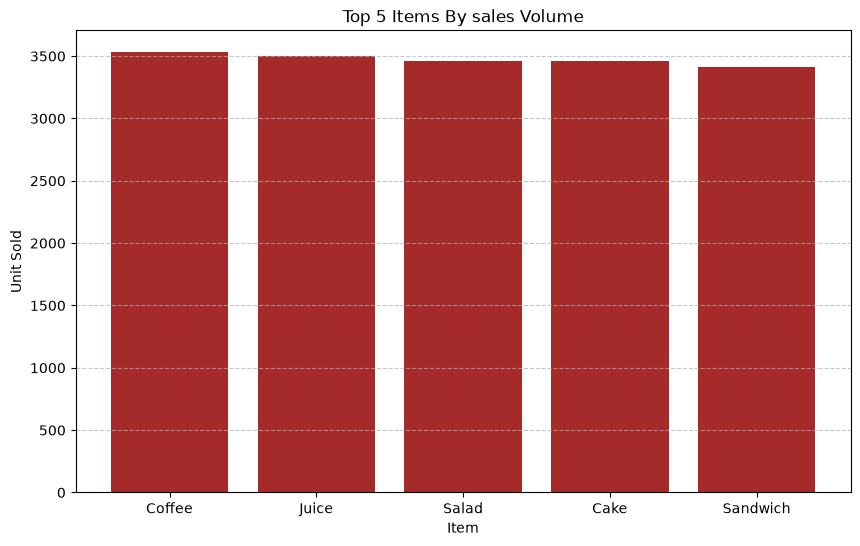

In [55]:
# Top 5 items 
top_5_items = top_items.head(5)
plt.figure(figsize=(10,6))
plt.bar(top_5_items.index, top_5_items.values, color="brown")

plt.title("Top 5 Items By sales Volume")
plt.xlabel("Item")
plt.ylabel("Unit Sold")
plt.grid(axis='y', linestyle='--', alpha=0.7)


plt.show()

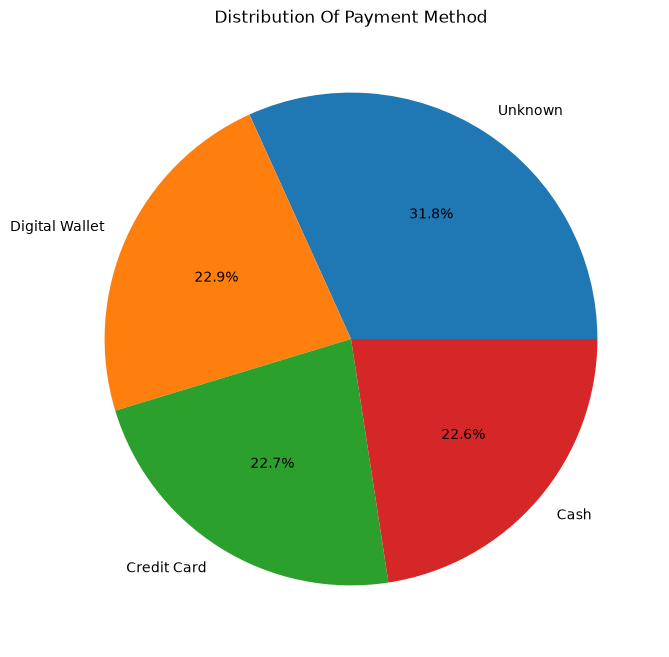

In [56]:
# visualize the payment method
plt.figure(figsize=(8,8))
plt.pie(
    payment_counts.values,
    labels = payment_counts.index,
    autopct = "%1.1f%%",
    
)

plt.title("Distribution Of Payment Method")


plt.show()

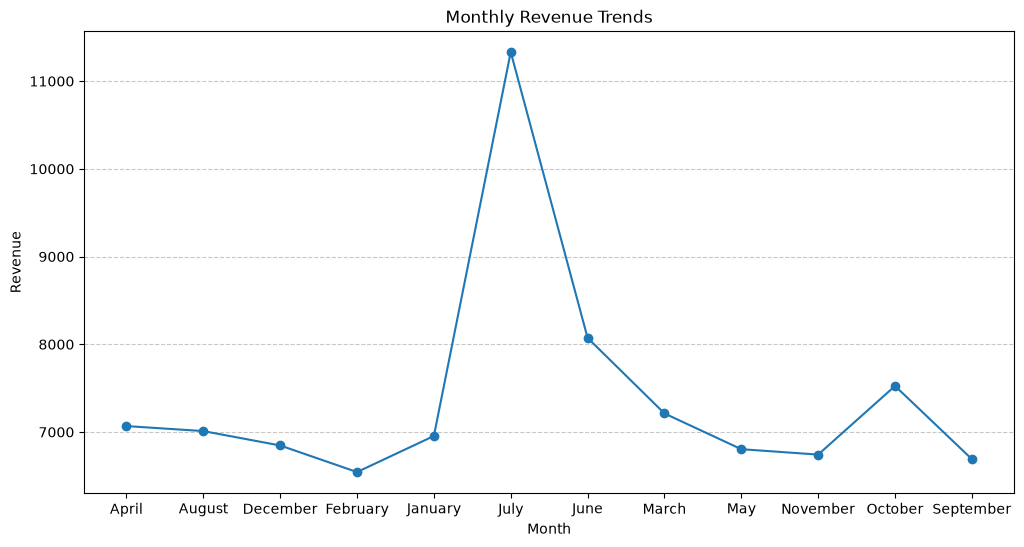

In [57]:
# Visualizing the monthly sales

plt.figure(figsize=(12,6))
plt.plot(
    monthly_sales.index.astype(str),
    monthly_sales.values,
    marker ="o"
)

plt.title("Monthly Revenue Trends")
plt.xlabel("Month")
plt.ylabel("Revenue")
plt.grid(axis='y', linestyle='--', alpha=0.7)


plt.show()

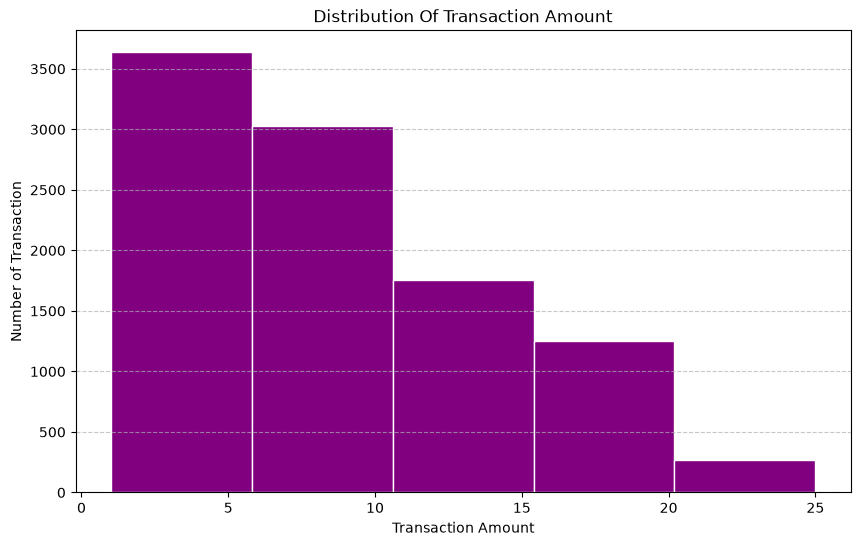

In [60]:
# Visualizing distribution by transaction amount
plt.figure(figsize=(10,6))
plt.hist(clean_df["Total Spent"], bins=5, edgecolor="white", color="purple")

plt.title("Distribution Of Transaction Amount")
plt.xlabel("Transaction Amount")
plt.ylabel("Number of Transaction")
plt.grid(axis='y', linestyle='--', alpha=0.7)


plt.show()

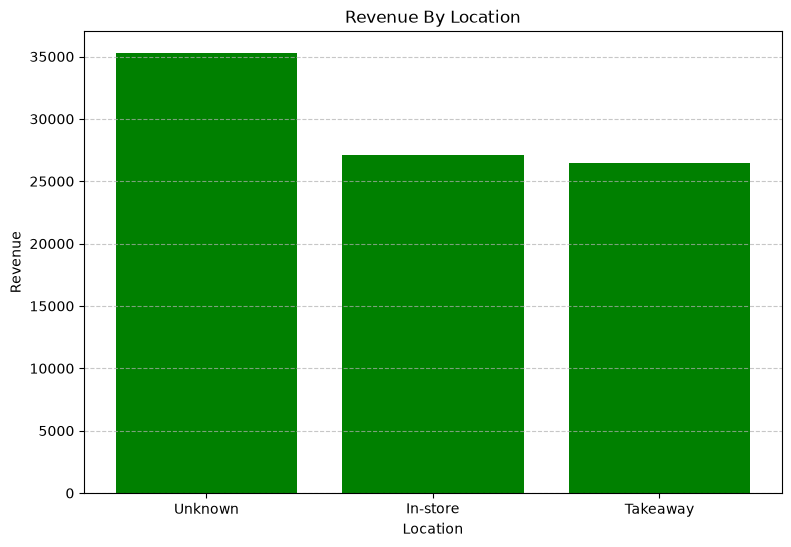

In [59]:
# Visualizing revenue by Location
plt.figure(figsize=(9,6))
plt.bar(revenue_by_location.index, revenue_by_location.values, color="green")

plt.title("Revenue By Location")
plt.xlabel("Location")
plt.ylabel("Revenue")
plt.grid(axis='y', linestyle='--', alpha=0.7)


plt.show()

## Summary Overview and Recommendation

### Insight Summary

The cleaned dataset contains 9,942 transactions with total revenue of 88,800.50 and an average transaction value of 8.93. Coffee recorded the highest sales volume with 3,529 units, followed by Juice (3,503) and Salad (3,463), indicating relatively strong demand across these products. However, revenue performance differs from sales volume: Salad generated the highest revenue at 17,315.00, followed by Sandwich at 13,644.00 and Smoothie at 13,296.00.

Sales performance varied considerably across the year. July was the strongest month, generating 11,331.50 in revenue, while February recorded the lowest at 6,543.50. Location analysis showed Unknown as the largest revenue category (35,280.00), followed by In-store (27,073.00) and Takeaway (26,447.50). However, the high Unknown values limit the reliability of location-based conclusions.

### Recommendations

The cafe should prioritize high-revenue products such as Salad, Sandwich, and Smoothie while maintaining strong availability of high-volume products such as Coffee and Juice. Management should also investigate the factors behind July's stronger performance and consider applying successful strategies during slower periods such as February.

A major operational priority should be improving data collection. With 3,158 transactions recorded with an Unknown payment method and 3,940 transactions with an Unknown location, the current records significantly limit customer and channel analysis. Mandatory payment and location fields, standardized data-entry options, and regular data-quality checks would provide more reliable information for future business decisions.
